In [6]:
import pandas as pd
import yaml
import os

def parse_yaml_file(filepath):
    """
    Parses a single YAML file and extracts relevant data.

    Args:
        filepath (str): The full path to the YAML file.

    Returns:
        dict: A dictionary containing the parsed data with the filename as a key.
    """
    with open(filepath, 'r') as file:
        data = yaml.safe_load(file)
    return data

def process_data_for_dataframe(data, source_name):
    """
    Processes the parsed YAML data into a flat format suitable for a Pandas DataFrame.

    Args:
        data (dict): The dictionary parsed from a YAML file.
        source_name (str): The name of the source (e.g., directory name or filename prefix).

    Returns:
        list: A list of dictionaries, each representing a row in the DataFrame.
    """
    rows = []
    for model_name, model_data in data.items():
        row_base = {
            'source': source_name,
            'model': model_name,
            'clustering_score': model_data.get('clustering_score'),
            'total_number_edges': model_data.get('total_number_edges')
        }
        for key, value in model_data.items():
            if isinstance(value, dict) and key.startswith('net_'):
                # Extract net-specific details
                row = row_base.copy()
                row['net_id'] = key
                row['net_size'] = value.get('net_size')
                row['edge_overlap'] = value.get('edge_overlap')
                row['overlap_percent'] = value.get('overlap_percent')
                rows.append(row)
            elif not isinstance(value, dict) and key not in ['clustering_score', 'total_number_edges']:
                # Handle other top-level keys if they exist and are not dictionaries
                # This part might need adjustment based on expected YAML structure variations
                row = row_base.copy()
                row[key] = value
                rows.append(row)
        # If there are no 'net_' entries, still add a row for the main model data
        if not any(k.startswith('net_') for k in model_data.keys()):
            rows.append(row_base)
    return rows


def create_dataframe_from_yaml_data(yaml_data_collection):
    """
    Creates a pandas DataFrame from a collection of processed YAML data.

    Args:
        yaml_data_collection (list): A list of processed data rows.

    Returns:
        pandas.DataFrame: The resulting DataFrame.
    """
    return pd.DataFrame(yaml_data_collection)

def parse_yaml_files_in_directory(directory_path):
    """
    Parses all YAML files in a given directory and consolidates their data into a DataFrame.

    Args:
        directory_path (str): The path to the directory containing the YAML files.

    Returns:
        pandas.DataFrame: A DataFrame containing data from all parsed YAML files.
    """
    all_processed_rows = []
    # Assuming the directory name itself is the 'source' or if you have a specific file naming convention.
    # For this example, I'll use the directory name as the source.
    source_name = os.path.basename(directory_path.rstrip(os.sep))

    for dirname in os.listdir(directory_path):
        filepath = os.path.join(directory_path, dirname, 'results.yaml')
        print(f"Parsing {filepath}...")
        raw_data = parse_yaml_file(filepath)
        processed_rows = process_data_for_dataframe(raw_data, source_name)
        all_processed_rows.extend(processed_rows)

    return create_dataframe_from_yaml_data(all_processed_rows)



In [8]:

# Create dummy files for demonstration purposes
# In a real scenario, these files would already exist in your directory.
results_directory = "/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries"


# Now, call the function with the path to your directory
# Replace 'my_yaml_results' with the actual path to your directory containing the YAML files.
df = parse_yaml_files_in_directory(results_directory)

df


Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_105_14145_net_76_12762_net_51_13833/results.yaml...
Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_73_13912_net_105_14145_net_82_12606/results.yaml...
Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_63_13257_net_51_13886_net_94_13945/results.yaml...
Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_67_13435_net_142_13109_net_76_12762/results.yaml...
Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_64_14022_net_94_13945_net_53_13523/results.yaml...
Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_81_12858_net_191_13317_net_59_13649/results.yaml...
Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_76_12762_net_158_13767_net_164_12996/results.yaml...
Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_172_13576_net_131_13677_net_158_13767/results

,source,model,clustering_score,total_number_edges,net_id,net_size,edge_overlap,overlap_percent
0,summaries,csnet,0.516000,31,net_105_14145,110,0,0.000000
1,summaries,csnet,0.516000,31,net_76_12762,163,0,0.000000
2,summaries,scgenerai,0.500000,26796,net_105_14145,110,39,0.354545
3,summaries,scgenerai,0.500000,26796,net_76_12762,163,112,0.687117
4,summaries,csnet,0.508000,146,net_105_14145,110,0,0.000000
5,summaries,csnet,0.508000,146,net_73_13912,91,0,0.000000
6,summaries,netmap,0.998956,27534,net_105_14145,110,16,0.145455
7,summaries,netmap,0.998956,27534,net_73_13912,91,35,0.384615
8,summaries,scgenerai,0.501000,33670,net_105_14145,110,39,0.354545
9,summaries,scgenerai,0.501000,33670,net_73_13912,91,51,0.560440


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import os

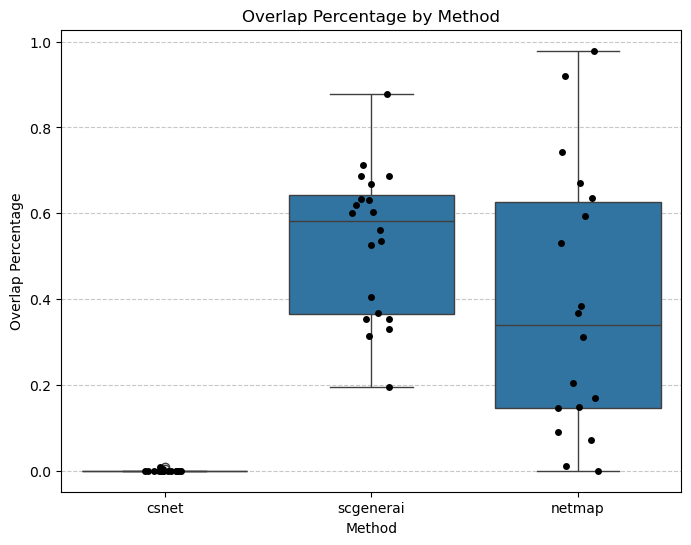

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='model', y='overlap_percent', data=df)
sns.stripplot(x='model', y='overlap_percent', data=df, color='black', size=5, jitter=True) # Adds individual points
plt.title('Overlap Percentage by Method')
plt.xlabel('Method')
plt.ylabel('Overlap Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

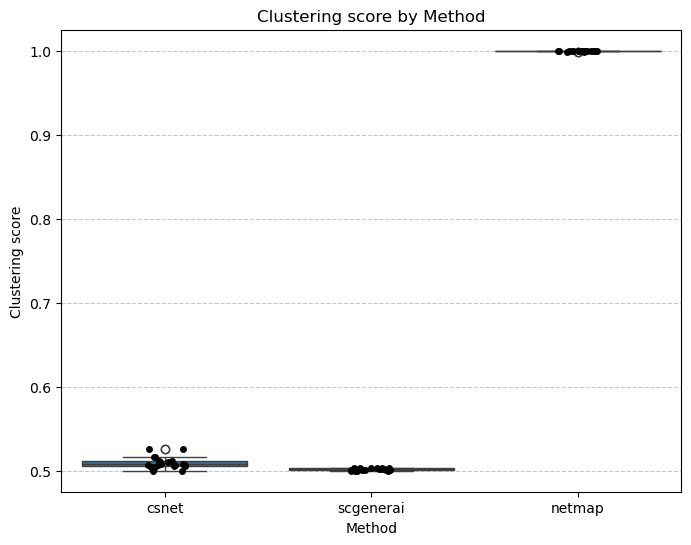

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='model', y='clustering_score', data=df)
sns.stripplot(x='model', y='clustering_score', data=df, color='black', size=5, jitter=True) # Adds individual points
plt.title('Clustering score by Method')
plt.xlabel('Method')
plt.ylabel('Clustering score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [162]:
import pandas as pd
import yaml
import os

def parse_network_paths_data(data):
    """
    Parses the provided dictionary data into a list of dictionaries,
    suitable for creating a Pandas DataFrame.

    Args:
        data (dict): The dictionary parsed from the YAML-like structure.

    Returns:
        list: A list of dictionaries, each representing a row in the DataFrame.
    """
    rows = []
    for net_id, net_data in data.items():
        # Iterate through each method (csnet, netmap, scgenerai, data_simulation)
        for method_name, method_details in net_data.items():
            if method_name == 'data_simulation':
                # Data simulation has 'configs' and 'data_path' keys
                continue                
            else:
                # Other methods have 'config_easy' which contains 'config' and 'result'
                result_path = method_details.get('config_easy', {}).get('result')

            rows.append({
                'network_id': net_id,
                'method': method_name,
                'result_path': result_path
            })
    return rows

import os.path as op
import numpy as np
def create_dataframe_from_paths(data_to_parse):
    """
    Creates a Pandas DataFrame from the parsed network path data.

    Args:
        data_to_parse (dict): The raw dictionary content from the YAML-like structure.

    Returns:
        pandas.DataFrame: A DataFrame containing the network IDs, methods,
                          and their corresponding config and result paths.
    """
    processed_rows = parse_network_paths_data(data_to_parse)
    df = pd.DataFrame(processed_rows)
    return df


def read_all_timings(data):
    times = []
    for row, content in data.iterrows():
        try:
            mylist = content['result_path'].split('/')[-4:]
            time = parse_yaml_file(op.join(content['result_path'], 'results.yaml'))
            mylist.append(time['time_elapsed_total'])
            mylist.append(time[f'time_elapsed_{mylist[0]}'])
            times.append(mylist)
        except:
            continue
        
    times = pd.DataFrame(np.stack(times))
    times.columns = ['method', 'method_config', 'data_config', 'net', 'time_total', 'time_method']
    times['time_method'] = times['time_method'].astype( float)
    times['time_total'] = times['time_total'].astype( float)
    
    return times

In [108]:
yaml_content = parse_yaml_file('/data_nfs/og86asub/netmap/netmap-evaluation/all_tests.yaml')

In [109]:

df = create_dataframe_from_paths(yaml_content)



In [169]:
times = read_all_timings(df)
times['time_method_minutes'] = times['time_method']/60


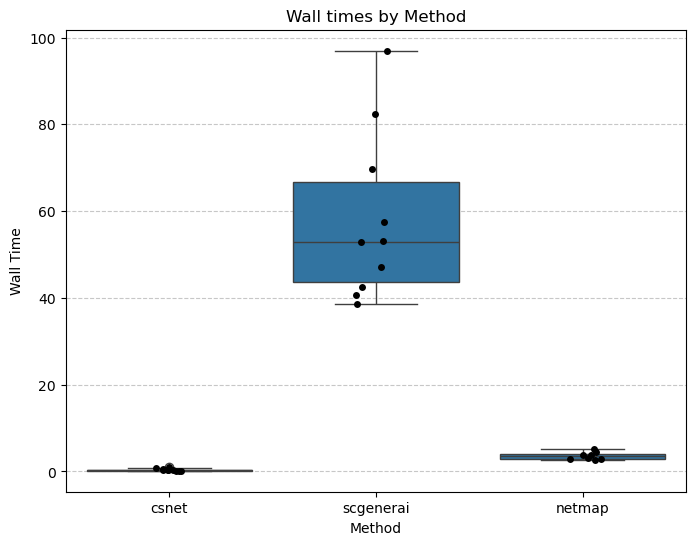

In [170]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='method', y='time_method_minutes', data=times)
sns.stripplot(x='method', y='time_method_minutes', data=times, color='black', size=5, jitter=True) # Adds individual points
plt.title('Wall times by Method')
plt.xlabel('Method')
plt.ylabel('Wall Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()